In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader

In [2]:
# CHECK CUDA

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)


cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PATH = "/content/drive/MyDrive/SKRISPI/data_final.csv"

In [5]:
df = pd.read_csv(PATH)
df

,Text,Label
0,kata gue lu pada jangan moots sama akun akun k...,Kata Kasar dan Vulgar
1,km dari titik jemput tolol sih gojek,Kata Kasar dan Vulgar
2,INDOSAT KONTOL BABI ANJING USER USER HARI SINY...,Kata Kasar dan Vulgar
3,USER yapp tiap hari gw sepong kontol nya pagi²...,Sexual Harassment
4,dion lo gak pernah fokus sama misi ini lo itu ...,Kata Kasar dan Vulgar
...,...,...
19675,USER kalo lo nyari yang kenceng ya vivo yd pro...,Non-Cyberbullying
19676,tadi coba kamera iphone promex terus ngeliat m...,Non-Cyberbullying
19677,gue kalo siang sore galau pgn kabur tp kalo ma...,Non-Cyberbullying
19678,makanya kalo pelatih minta beli pemain diturut...,Kata Kasar dan Vulgar


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df


,Text,Label
0,kata gue lu pada jangan moots sama akun akun k...,Kata Kasar dan Vulgar
1,km dari titik jemput tolol sih gojek,Kata Kasar dan Vulgar
2,INDOSAT KONTOL BABI ANJING USER USER HARI SINY...,Kata Kasar dan Vulgar
3,USER yapp tiap hari gw sepong kontol nya pagi²...,Sexual Harassment
4,dion lo gak pernah fokus sama misi ini lo itu ...,Kata Kasar dan Vulgar
...,...,...
16569,USER kalo lo nyari yang kenceng ya vivo yd pro...,Non-Cyberbullying
16570,tadi coba kamera iphone promex terus ngeliat m...,Non-Cyberbullying
16571,gue kalo siang sore galau pgn kabur tp kalo ma...,Non-Cyberbullying
16572,makanya kalo pelatih minta beli pemain diturut...,Kata Kasar dan Vulgar


In [7]:
df["Label"].value_counts()

,count
Label,
Kata Kasar dan Vulgar,11769
Non-Cyberbullying,2146
Sexual Harassment,1023
Hate Speech,937
Body Shaming,699


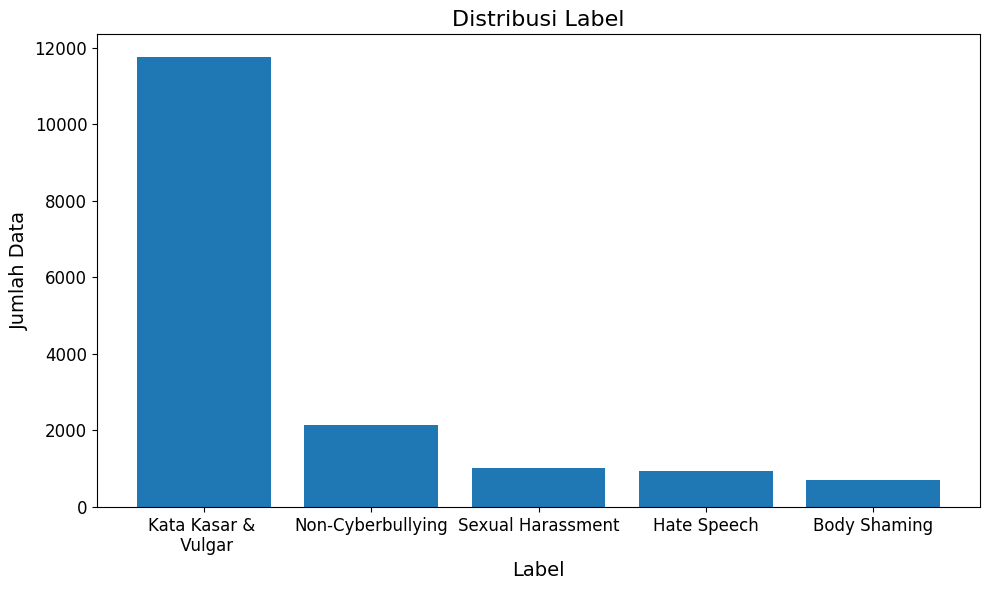

In [9]:
# LABEL VISUALIZATION

label_counts = df['Label'].value_counts()

label_display = {
    'Kata Kasar dan Vulgar': 'Kata Kasar & \n Vulgar'
}

labels = [
    label_display.get(label, label)
    for label in label_counts.index
]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, label_counts.values)

plt.title('Distribusi Label', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Jumlah Data', fontsize=14)

# Ukuran tulisan sumbu
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# DECLARE X AND Y
X = df['Text']
y = df['Label']

In [ ]:
# DATA SPLIT
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [ ]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 13259
Validation: 1657
Test: 1658


In [ ]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Label
Kata Kasar dan Vulgar    0.710084
Non-Cyberbullying        0.129497
Sexual Harassment        0.061694
Hate Speech              0.056565
Body Shaming             0.042160
Name: proportion, dtype: float64
Label
Kata Kasar dan Vulgar    0.710320
Non-Cyberbullying        0.129149
Sexual Harassment        0.061557
Hate Speech              0.056729
Body Shaming             0.042245
Name: proportion, dtype: float64
Label
Kata Kasar dan Vulgar    0.709891
Non-Cyberbullying        0.129674
Sexual Harassment        0.062123
Hate Speech              0.056092
Body Shaming             0.042220
Name: proportion, dtype: float64


In [ ]:
# LABEL ENCODING
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Body Shaming' 'Hate Speech' 'Kata Kasar dan Vulgar' 'Non-Cyberbullying'
 'Sexual Harassment']


In [ ]:
# APPLY TOKENIZER
tokenizer = AutoTokenizer.from_pretrained(
    "indolem/indobertweet-base-uncased"
)

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/235k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(X_val),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(train_encodings["input_ids"][3])

print(tokens[:10])
print(train_encodings["input_ids"][3][:10])
print(train_encodings["attention_mask"][3][:10])

['[CLS]', 'user', 'emg', 'cupu', 'lu', 'kira', 'jago', '[SEP]', '[PAD]', '[PAD]']
[3, 12287, 7418, 30924, 4578, 4159, 11447, 4, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 0]


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(train_encodings["input_ids"][0])

print(tokens[:10])
print(train_encodings["input_ids"][0][:10])
print(train_encodings["attention_mask"][0][:10])

['[CLS]', 'user', 'iya', 'gpp', 'col', '##mek', 'aj', 'neng', '[SEP]', '[PAD]']
[3, 12287, 13888, 9306, 2777, 29675, 2740, 12745, 4, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 0]


In [ ]:
lengths = [len(tokenizer.tokenize(text)) for text in df["Text"]]

print(max(lengths))
print(np.mean(lengths))
print(np.percentile(lengths, 95))

263
22.54905273319657
52.0


In [ ]:
class CyberbullyingDataset(Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels)

In [ ]:
train_dataset = CyberbullyingDataset(
    train_encodings,
    y_train_encoded
)

val_dataset = CyberbullyingDataset(
    val_encodings,
    y_val_encoded
)

test_dataset = CyberbullyingDataset(
    test_encodings,
    y_test_encoded
)

In [ ]:
# DECLARE FOCAL LOSS CLASS
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha  # bisa tensor class weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs = logits (belum softmax)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        pt = torch.exp(-ce_loss)  # prob of correct class

        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
# DECLARE INDOBERTWEET BIGRU MODELING
class IndoBERTweetBiGRU(nn.Module):

    def __init__(
        self,
        bert_model="indolem/indobertweet-base-uncased",
        hidden_size=128,
        num_classes=5,
        dropout=0.3
    ):

        super(IndoBERTweetBiGRU, self).__init__()

        # IndoBERTweet
        self.bert = AutoModel.from_pretrained(
            bert_model
        )

        # BiGRU
        self.bigru = nn.GRU(
            input_size=768,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected
        self.fc = nn.Linear(
            hidden_size * 2,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state

        gru_output, hidden = self.bigru(
            sequence_output
        )

        forward_hidden = hidden[-2]

        backward_hidden = hidden[-1]

        hidden_concat = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        x = self.dropout(hidden_concat)

        logits = self.fc(x)

        return logits


In [ ]:
HIDDEN_SIZE = 128

In [ ]:
num_classes = len(label_encoder.classes_)

model = IndoBERTweetBiGRU(
    hidden_size=HIDDEN_SIZE,
    num_classes=num_classes,
    dropout=0.3
)

model = model.to(device)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
LEARNING_RATE = 2e-5

In [ ]:
# LOSS AND OPTIMIZER

criterion = FocalLoss(gamma=2.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [ ]:
BATCH_SIZE = 16

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
EPOCHS = 4

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [ ]:
for epoch in range(EPOCHS):

    # TRAINING

    model.train()

    train_loss = 0

    train_preds = []
    train_labels = []

    for batch in train_loader:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch[
            'attention_mask'
        ].to(device)

        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(
            preds.cpu().numpy()
        )

        train_labels.extend(
            labels.cpu().numpy()
        )

    avg_train_loss = train_loss / len(train_loader)

    train_acc = accuracy_score(
        train_labels,
        train_preds
    )

    # VALIDATION ACCURACY AND LOSS

    model.eval()

    val_loss = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch[
                'input_ids'
            ].to(device)

            attention_mask = batch[
                'attention_mask'
            ].to(device)

            labels = batch[
                'labels'
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            preds = torch.argmax(
                outputs,
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    avg_val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(
        val_labels,
        val_preds
    )

    #TEST ACCURACY AND LOSS

    test_loss = 0

    test_preds = []
    test_labels = []

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch[
                'input_ids'
            ].to(device)

            attention_mask = batch[
                'attention_mask'
            ].to(device)

            labels = batch[
                'labels'
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(
                outputs,
                labels
            )

            test_loss += loss.item()

            preds = torch.argmax(
                outputs,
                dim=1
            )

            test_preds.extend(
                preds.cpu().numpy()
            )

            test_labels.extend(
                labels.cpu().numpy()
            )

    avg_test_loss = test_loss / len(test_loader)

    test_acc = accuracy_score(
        test_labels,
        test_preds
    )

    # SAVE HISTORY

    train_losses.append(
        avg_train_loss
    )

    val_losses.append(
        avg_val_loss
    )

    train_accuracies.append(
        train_acc
    )

    val_accuracies.append(
        val_acc
    )

    # SHOW RESULT

    print(f"\nEpoch {epoch+1}")

    print(
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {val_acc:.4f}"
    )

    print(
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Accuracy: {test_acc:.4f}"
    )


Epoch 1
Train Loss: 0.1770 | Train Accuracy: 0.8709
Val Loss: 0.1250 | Val Accuracy: 0.9004
Test Loss: 0.1209 | Test Accuracy: 0.9083

Epoch 2
Train Loss: 0.0754 | Train Accuracy: 0.9333
Val Loss: 0.1046 | Val Accuracy: 0.9137
Test Loss: 0.0969 | Test Accuracy: 0.9198

Epoch 3
Train Loss: 0.0417 | Train Accuracy: 0.9598
Val Loss: 0.0903 | Val Accuracy: 0.9203
Test Loss: 0.0907 | Test Accuracy: 0.9331

Epoch 4
Train Loss: 0.0232 | Train Accuracy: 0.9763
Val Loss: 0.1157 | Val Accuracy: 0.9101
Test Loss: 0.1063 | Test Accuracy: 0.9258


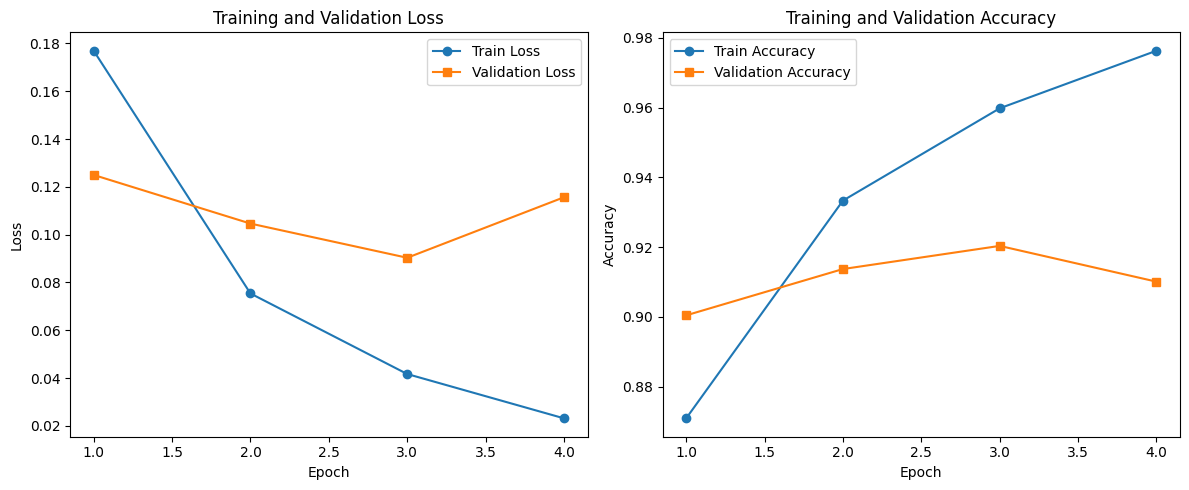

In [ ]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    EPOCHS + 1
)

plt.figure(
    figsize=(12, 5)
)

# LOSS
plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='s',
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title(
    'Training and Validation Loss'
)

plt.legend()


# ACCURACY
plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    train_accuracies,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    marker='s',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title(
    'Training and Validation Accuracy'
)

plt.legend()


plt.tight_layout()

plt.savefig(
    'training_progress.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
model.eval()

test_preds = []
test_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            'input_ids'
        ].to(device)

        attention_mask = batch[
            'attention_mask'
        ].to(device)

        labels = batch[
            'labels'
        ].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        test_preds.extend(
            preds.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )


print(classification_report(
    test_labels,
    test_preds,
    target_names=label_encoder.classes_
))

                       precision    recall  f1-score   support

         Body Shaming       0.90      0.76      0.82        70
          Hate Speech       0.80      0.91      0.85        93
Kata Kasar dan Vulgar       0.98      0.94      0.96      1177
    Non-Cyberbullying       0.78      0.94      0.85       215
    Sexual Harassment       0.81      0.86      0.84       103

             accuracy                           0.93      1658
            macro avg       0.85      0.88      0.87      1658
         weighted avg       0.93      0.93      0.93      1658



In [ ]:
model.eval()

IndoBERTweetBiGRU(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
class_names = [
    'BS',
    'HS',
    'RW',
    'NCB',
    'SH'
]

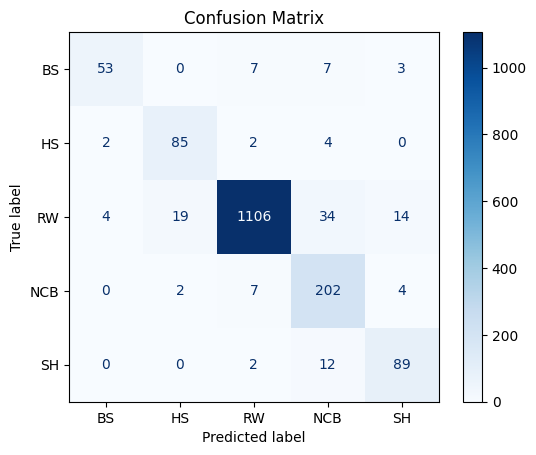

In [ ]:
cm = confusion_matrix(
    test_labels,
    test_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.show()

## Model Testing

In [ ]:
id_label = {
    0: "Body Shaming",
    1: "Hate Speech",
    2: "Kata Kasar dan Vulgar",
    3: "Non-Cyberbullying",
    4: "Sexual Harassment"
}

In [ ]:
def predict_text(text):

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs, dim=1)

        pred = torch.argmax(probs, dim=1).item()

    print(f"Text: {text}")
    print(f"Prediction: {id2label[pred]}")
    print(f"Probabilities: {probs.cpu().numpy()}")

In [ ]:
predict_text("dasar goblok banget lu")

Text: dasar goblok banget lu
Prediction: Kata Kasar dan Vulgar
Probabilities: [[0.00381493 0.00457863 0.9878814  0.00188732 0.00183769]]


In [ ]:
predict_text("gue bego banget barusan numpahin es")

Text: gue bego banget barusan numpahin es
Prediction: Non-Cyberbullying
Probabilities: [[0.00172637 0.00645784 0.01440536 0.973517   0.00389339]]


In [ ]:
predict_text("kafir sialan")

Text: kafir sialan
Prediction: Hate Speech
Probabilities: [[0.00317214 0.97597855 0.00585262 0.01312034 0.00187632]]


In [ ]:
predict_text("lu cungkring item tampang gendut kek gitu")

Text: lu cungkring item tampang gendut kek gitu
Prediction: Body Shaming
Probabilities: [[0.9592456  0.00488877 0.01243628 0.019987   0.00344236]]


In [ ]:
predict_text("sebenernya anjing tuh makannya apa sih")

Text: sebenernya anjing tuh makannya apa sih
Prediction: Non-Cyberbullying
Probabilities: [[0.00379633 0.03506822 0.06357419 0.8878617  0.00969951]]


In [ ]:
predict_text("kamu mau aku jilmek gak")

Text: kamu mau aku jilmek gak
Prediction: Sexual Harassment
Probabilities: [[0.00443178 0.00623108 0.00488301 0.21436101 0.7700931 ]]


In [ ]:
torch.save(model.state_dict(), "model_indobertweetbigru.pth")